# Week 1 Mini Project

## Overview

This notebook combines everything learned throughout **Week1** into a complete data analysis workflow.

The project follows the standard Data Analysis pipeline: 

**Load Data -> Explore -> Clean -> Analyze -> Visualize**

By the end of this notebook, I will:

- Load and inpect a real dataset.
- Clean missing and inconsistent data.
- Preform numerical analysis using NumPy.
- Create infomative visulizations with Matplotlib.
- Summarize the insights discovered from tha dataset.

## Learning Objectives

In this notebook, I will Practice how to:

- Load and inspect datasets using Pandas.
- Perform basic preprocessing.
- Compute numerical statistics with NumPy.
- Create different chart types using Matlotlib.
- Build a small end-to-end data analysis project.

## Libraries Used 

The following libraries will be used throughout this notebook:

- **NumPy** for numerical computations.
- **Pandas** for data manipulation.
- **Matplotlib** for data visualization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Display plots inside the notebook
%matplotlib inline

# Step 1: Load the dataset

The first step in any data analysis project is loading the dataset into a Pandas DataFrame.

This dataset contains information about students enrolled in online courses.

In [4]:
df = pd.read_csv("Students_Courses.csv")

df.head()

,StudentID,Name,StudyTime,Score,Level,Completed,City
0,801,Ali,2.0,70.0,Beginner,Yes,Nablus
1,802,Sara,5.0,85.0,beginner,Yes,Ramallah
2,803,Omar,NaN,60.0,Intermediate,No,nablus
3,804,Lina,10.0,150.0,Advanced,Yes,Jenin
4,805,Noor,-3.0,40.0,Intermediate,No,Jenin


### Observation

The first five rows provide an initial overview of tha dataset, including the available features and some sample values.

Inpecting the data early helps identify possiple quality issues before analysis.

# Step 2: Explore the Dataset

Before cleaning or visualizing the data, Is is important to understand its overall structure.

In [5]:
df.shape

(12, 7)

The `shape` attribute returns the number of rows and columns in the dataset.

In [6]:
df.columns

Index(['StudentID', 'Name', 'StudyTime', 'Score', 'Level', 'Completed',
       'City'],
      dtype='str')

The dataset contains several features describing each student's learning information.

In [7]:
df.dtypes

StudentID      int64
Name             str
StudyTime    float64
Score        float64
Level            str
Completed        str
City             str
dtype: object

understanding the data types helps detemine how each column should be processed during analysis.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   StudentID  12 non-null     int64  
 1   Name       12 non-null     str    
 2   StudyTime  11 non-null     float64
 3   Score      11 non-null     float64
 4   Level      12 non-null     str    
 5   Completed  12 non-null     str    
 6   City       12 non-null     str    
dtypes: float64(2), int64(1), str(4)
memory usage: 804.0 bytes


The `info()` function provides:

- Number of rows
- Number of non-null values
- Data types
- Memory usage

It is one of the fastest ways to inspect a dataset.

In [9]:
df.describe()

,StudentID,StudyTime,Score
count,12.000000,11.000000,11.000000
mean,806.500000,4.181818,78.000000
std,3.605551,4.238353,29.189039
min,801.000000,-3.000000,40.000000
25%,803.750000,2.000000,62.500000
50%,806.500000,4.000000,70.000000
75%,809.250000,5.500000,86.500000
max,812.000000,12.000000,150.000000


`describe()` generates descriptive statistics for numerical columns, including:

- Count
- Mean
- Standard Daviation
- Minimum
- Maximum
- Quartiles

These statisitcs provide a quick summary of the dataset before further analysis.

In [10]:
df.sample()

,StudentID,Name,StudyTime,Score,Level,Completed,City
10,811,Mona,3.0,65.0,Intermediate,No,Jericho


Unlike `head()`, which always diplays the first rows, `sample()` returns random records.

Random sampling helps verify that the dataset is representative and may several issues not available in the first few rows.

## Initial Observations

From the initial exploration, I observed that:

- The dataset contains both numerical and categorical features.
- Some columns contain missing values.
- The data requires cleaning before visualization.
- The dataset is suitable for practicing the complete data analysis workflow.

# Step 3: Data Cleaning

Real-world datasets are rarely perfect.

Before analyzing or visualizing the data, it is important to clean the dataset by handling missing values, removing duplicates, and fixing inconsistent or invalid data.

## 3.1 Missing Values

Missing values can affect calculations and visualizations.

The first step is identifying where they exist.

In [11]:
df.isnull().sum()

StudentID    0
Name         0
StudyTime    1
Score        1
Level        0
Completed    0
City         0
dtype: int64

The output shows missing values in the **StudyTime** and **Score** columns.

Instead of removing these rows, I will replace the missing values with the column mean to preserve the dataset size.

In [12]:
df["StudyTime"] = df["StudyTime"].fillna(df["StudyTime"].mean())
df["Score"] = df["Score"].fillna(df["Score"].mean())

In [13]:
df.isnull().sum()

StudentID    0
Name         0
StudyTime    0
Score        0
Level        0
Completed    0
City         0
dtype: int64

The dataset no longer contains missing values in the numerical columns.

## 3.2 Duplicates Records

Duplicate rows can introduce bias into the analysis.

The following code checks whether duplicate records exist.

In [14]:
df.duplicated().sum()

np.int64(0)

The dataset has no duplicated rows.

## 3.3 Standardizing Text Values

Categorical values should use a consistent format.

For example, "Beginner" and "beginner" represent the same category but are treated as different values.

In [15]:
df["Level"] = df["Level"].str.title()
df["City"] = df["City"].str.title()

In [16]:
print(df["Level"].unique())
print(df["City"].unique())

<StringArray>
['Beginner', 'Intermediate', 'Advanced']
Length: 3, dtype: str
<StringArray>
['Nablus', 'Ramallah', 'Jenin', 'Hebron', 'Tulkarm', 'Jericho']
Length: 6, dtype: str


After standardization, categorical values use capitalization, improving data quality.

## 3.4 Removing Invalid Values

Some numerical values fall outside the expected range.

These records should be removed before analysis.

In [17]:
df = df[(df["Score"] >= 0) & (df["Score"] <= 100)]
df = df[df["StudyTime"] >= 0]

In [18]:
df.reset_index(drop=True, inplace=True)

The index has been reset after removing invalid records to maintain a clean and continuous DataFrame.

## 3.5 Final Dataset Check

After preprocessing, I performed one final inspection to ensure that the dataset is clean and ready for analysis.

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   StudentID  10 non-null     int64  
 1   Name       10 non-null     str    
 2   StudyTime  10 non-null     float64
 3   Score      10 non-null     float64
 4   Level      10 non-null     str    
 5   Completed  10 non-null     str    
 6   City       10 non-null     str    
dtypes: float64(2), int64(1), str(4)
memory usage: 692.0 bytes


In [21]:
df.describe()

,StudentID,StudyTime,Score
count,10.000000,10.000000,10.00000
mean,806.900000,4.318182,74.60000
std,3.842742,3.232142,14.04912
min,801.000000,0.000000,50.00000
25%,803.750000,2.250000,66.25000
50%,807.500000,4.090909,74.00000
75%,809.750000,5.000000,85.00000
max,812.000000,12.000000,95.00000


### Summary

The dataset has now been preprocessed by:

- Handling missing values
- Removing duplicate records
- Standardizing text values
- Removing Invalid numerical Values
- Resetting the index

The cleaned dataset is now ready for numerical analysis and visualization.

# Step 4: Numerical Analysis with NumPy

After cleaning the dataset, I can use NumPy to perform numerical computations and summarize the data.

NumPy provides fast and effecient mathematical operations that are commonly used during data analysis.

## Average Score

The average score provides as overall measure of student preformance.

In [25]:
average_score = np.mean(df["Score"])

print(f"Average Score: {average_score:.2f}")

Average Score: 74.60


The mean represents the central value of all student's score.

## Average study time

The average study time indicates how much students study on average.

In [27]:
average_time = np.mean(df["StudyTime"])

print(f"Average Study Time: {average_time:.2f} hours")

Average Study Time: 4.32 hours


The average study time helps describe student's learning habits.

## Maximum and Minimum Scores

Finding the highest and lowest scores helps identify the preformance range.

In [28]:
print("Maximum Score:", np.max(df["Score"]))
print("Minimum Score:", np.min(df["Score"]))

Maximum Score: 95.0
Minimum Score: 50.0


These values show the best and lowest student preformance in the dataset.

## Standard Deviation

Standard Deviation measures how spread out the scores are around the average.

In [29]:
score_std = np.std(df["Score"])

print(f"Standard Deviation: {score_std:.2f}")

Standard Deviation: 13.33


A larger standard deviation indicates greater variation in student scores, while a smaller value suggests that scores are closer to the avarege.

## Median Score

The median score represents the middle value after sorting all scores.

Unlike the mean, it is less affected by the extreme values.

In [30]:
median_score = np.median(df["Score"])

print(f"Median Score: {median_score}")

Median Score: 74.0


Comparing the mean and median provides insight into the distribution of the data whether it may be influenced by unusually high or low values.

## NumPy Summary

NumPy was used to compute several useful statistics:

- Average Score
- Average Study Time
- Maximum Score
- Minimum Score
- Median Score
- Standard Deviation

These statistics provide a numerical summary of the dataset before creating visualizations.

## Step 5: Data Visualization with Matplotlib

Visualization help transform numerical data into meaningful insights.

In this section, I will explore the dataset using different chart types, each serving a different purpose.

## 5.1 Histogram

A histogram shows how numerical values are distributed.

Here, I will visualize the distribution of student's scores.

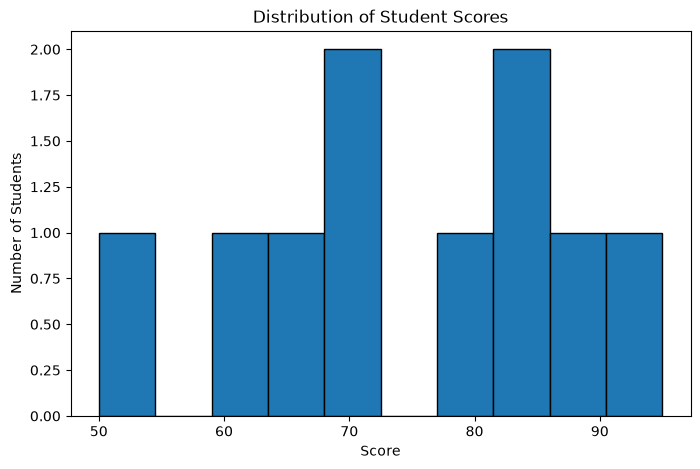

In [43]:
plt.figure(figsize=(8, 5))

plt.hist(df["Score"], bins=10, edgecolor="black")

plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Scores")

plt.show()

### Observation 

The histogram shows how student scores are distributed across different score ranges.

It help identify where most students are concentrated and whether thee scores are evenly distibuted or skewed.

## 5.2 Scatter Plot

Scatter plots are useful for exploring ralationships between two numerical variables.

In this example, I wil examine whether study time is related to student scores.

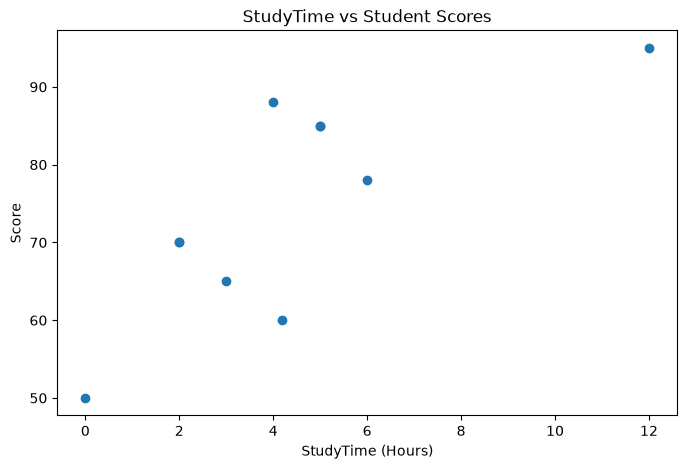

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(df["StudyTime"], df["Score"])

plt.xlabel("StudyTime (Hours)")
plt.ylabel("Score")
plt.title("StudyTime vs Student Scores")

plt.show()

### Observation

Each point represents one student.

This visualization helps identify whether students who spend more time studying tend to achieve higher scores.

## 5.3 Bar Chart

Bar charts compare values across different categories.

Here, I will compare the average score for each course level.

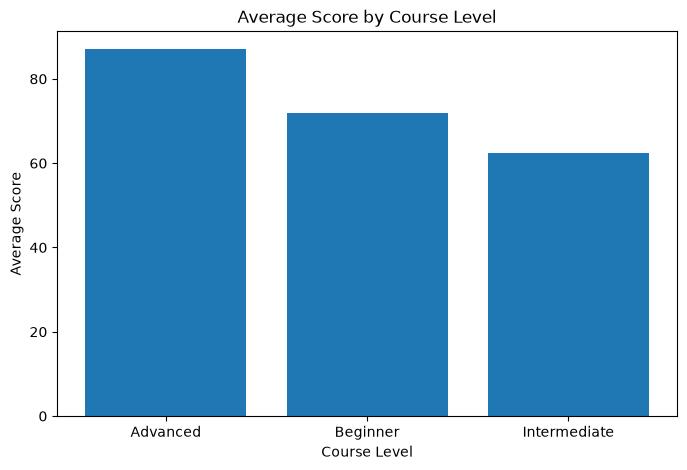

In [51]:
average_scores = df.groupby("Level")["Score"].mean()

plt.figure(figsize=(8, 5))

plt.bar(average_scores.index, average_scores.values)

plt.xlabel("Course Level")
plt.ylabel("Average Score")
plt.title("Average Score by Course Level")

plt.show()

### Observation

The bar chart compares the average student score across course levels.

It provides a quick comparison between categories and highlights preformance differences.

## 5.4 Line plot

Line plots are commonly used to display trends.

Although this dataset is not time-based, sorting the scores allows us to visualize how they change across students.

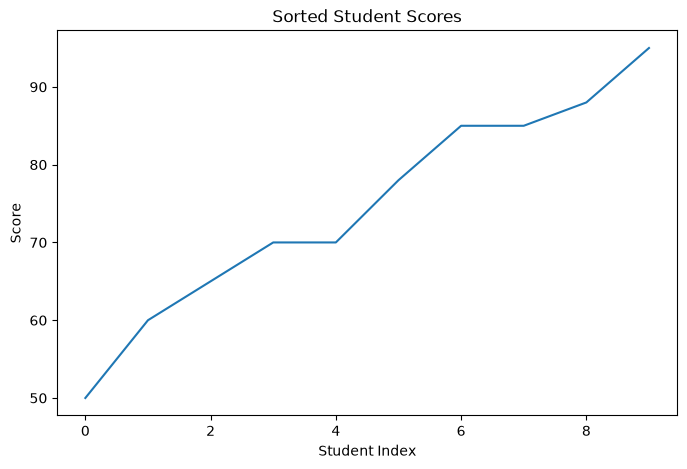

In [46]:
sorted_scores = np.sort(df["Score"])

plt.figure(figsize=(8, 5))

plt.plot(sorted_scores)

plt.xlabel("Student Index")
plt.ylabel("Score")
plt.title("Sorted Student Scores")

plt.show()

### Observation

The line plot illustrates the variation in student scores after sorting them in ascending order.

It provides a simple view of how scores change from the lowest to the highest value.

## Visualization summary

Different chart types reveal different aspects of the data:

- Histogrsm -> Distribution
- Scatter PLot -> Relationship
- Bar Chart -> Category Compatison
- Line Plot -> Trend

# Step 6: Subplots

Sometimes it is useful to compare multiple visualizations side by side.

Subplots allow multiple charts to be displayed within the same figure, making comparisom easier.

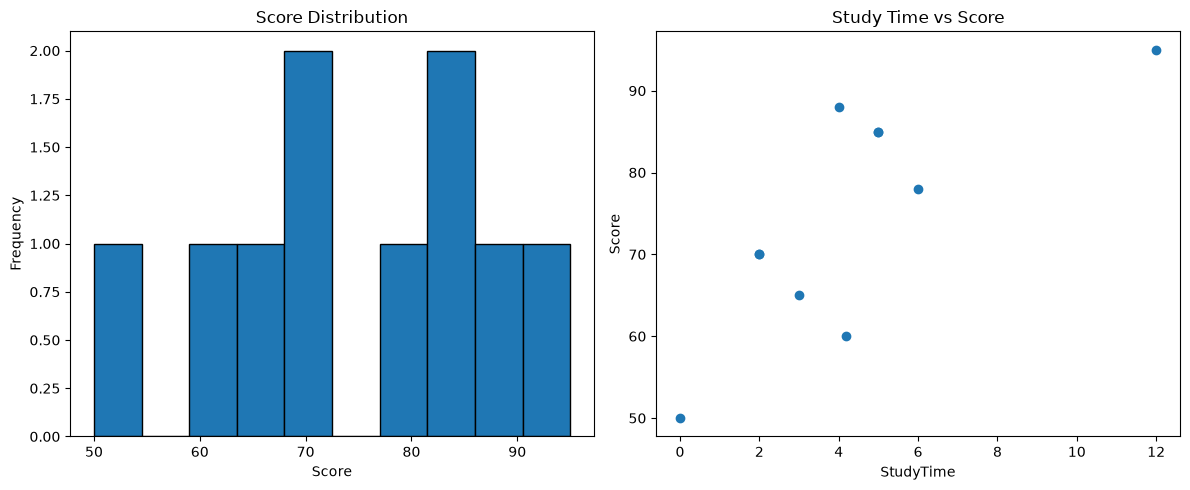

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(df["Score"], bins=10, edgecolor="black")
axes[0].set_title("Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")

# Scatter Plot
axes[1].scatter(df["StudyTime"], df["Score"])
axes[1].set_title("Study Time vs Score")
axes[1].set_xlabel("StudyTime")
axes[1].set_ylabel("Score") 

plt.tight_layout()
plt.show()

### Observation

The histogram provides an overview of the score distribution, while the scatter plot explores the relationship between study time and student performance.

Displaying both charts together makes it easier to compare different aspects of the dataset.

# Step 7: Project Findings

After exploring, cleaning, analyzing, and visualizing the dataset, several observations can be made.

## Findings

- The dataset initially contained missing values that were successfully handled.
- Duplicate and inconsistent records were cleaned during preprocessing.
- Most student scores fall within a specific score range, as shown in the histogram.
- The scatter plot suggests a possible relationship between study time and score.
- Average scores vary across different course levels.
- Visualizations make patterns easier to understand than numerical tables alone.

# Step 8: Week 1 Reflection

This notebook combines the main concepts learned throughout Week 1 into a single workflow.

The process followed was:

1. Load the dataset using Pandas.
2. Explore and understand the data.
3. Clean and preprocess the dataset.
4. Perform numerical analysis using NumPy.
5. Visualize the results using Matplotlib.

This workflow represents the foundation of many real-world data analysis and machine learning projects.

# Skills Practiced

During this project, I practiced:

- Python Programming
- NumPy computations
- Pandas data manipulation
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization with Matplotlib
- Building an end-to-end analysis workflow

# Conclusion

This mini project concludes the first week of the internship.

By integrating Python, NumPy, Pandas, and Matplotlib, I completed a simple data analysis workflow from loading raw data to presenting meaningful visual insights.

These skills provide a strong foundation for the upcoming topics in data analysis and machine learning.